# 🧠 Analysis of Mental Health Trends
### Data Science Minor Project — INT-375
**Student:** Aman Mishra | **Reg. No:** 12408177  
**Programme:** Computer Science and Engineering | **Section:** 4M029  
**University:** Lovely Professional University, Phagwara



## Project Overview
This notebook performs a full **Exploratory Data Analysis (EDA)**, **Visualization**, and **Interactive Dashboard** on the U.S. Mental Health Trends dataset — covering symptoms of **Anxiety Disorder**, **Depressive Disorder**, and their combined indicator across states, demographics, and time periods (2020–2024).

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
import matplotlib.dates as mdates
import panel as pn


import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.titleweight': 'bold'
})



In [34]:

df = pd.read_csv('mentalHealthRawdataset.csv')

print(f"Dataset Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns")

print("Column Names:")
for col in df.columns:
    print(f"   • {col}")

Dataset Shape   : 16,794 rows × 14 columns
Column Names:
   • Indicator
   • Group
   • State
   • Subgroup
   • Phase
   • Time Period
   • Time Period Label
   • Time Period Start Date
   • Time Period End Date
   • Value
   • Low CI
   • High CI
   • Confidence Interval
   • Quartile Range


In [35]:

df.head()

,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,Low CI,High CI,Confidence Interval,Quartile Range
0,Symptoms of Depressive Disorder,National Estimate,United States,United States,1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,23.5,22.7,24.3,22.7 - 24.3,NaN
1,Symptoms of Depressive Disorder,By Age,United States,18 - 29 years,1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,32.7,30.2,35.2,30.2 - 35.2,NaN
2,Symptoms of Depressive Disorder,By Age,United States,30 - 39 years,1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,25.7,24.1,27.3,24.1 - 27.3,NaN
3,Symptoms of Depressive Disorder,By Age,United States,40 - 49 years,1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,24.8,23.3,26.2,23.3 - 26.2,NaN
4,Symptoms of Depressive Disorder,By Age,United States,50 - 59 years,1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,23.2,21.5,25.0,21.5 - 25.0,NaN


In [36]:


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16794 entries, 0 to 16793
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Indicator               16794 non-null  object 
 1   Group                   16794 non-null  object 
 2   State                   16794 non-null  object 
 3   Subgroup                16794 non-null  object 
 4   Phase                   16794 non-null  object 
 5   Time Period             16794 non-null  int64  
 6   Time Period Label       16794 non-null  object 
 7   Time Period Start Date  16794 non-null  object 
 8   Time Period End Date    16794 non-null  object 
 9   Value                   16087 non-null  float64
 10  Low CI                  16087 non-null  float64
 11  High CI                 16087 non-null  float64
 12  Confidence Interval     16087 non-null  object 
 13  Quartile Range          11017 non-null  object 
dtypes: float64(3), int64(1), object(10)
me

In [37]:

cat_cols = ['Indicator', 'Group', 'Subgroup', 'State']
for col in cat_cols:
    print(f"\n {col} ({df[col].nunique()} unique):")
    print(f"   {df[col].unique().tolist()[:10]}")


 Indicator (3 unique):
   ['Symptoms of Depressive Disorder', 'Symptoms of Anxiety Disorder', 'Symptoms of Anxiety Disorder or Depressive Disorder']

 Group (9 unique):
   ['National Estimate', 'By Age', 'By Sex', 'By Race/Hispanic ethnicity', 'By Education', 'By State', 'By Disability status', 'By Gender identity', 'By Sexual orientation']

 Subgroup (78 unique):
   ['United States', '18 - 29 years', '30 - 39 years', '40 - 49 years', '50 - 59 years', '60 - 69 years', '70 - 79 years', '80 years and above', 'Male', 'Female']

 State (52 unique):
   ['United States', 'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia']


---
##  Section 2 — Data Preprocessing & Cleaning

In [38]:
# ─── Missing Value Analysis ────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)


(missing_df)

,Missing Count,Missing %
Quartile Range,5777,34.40
Value,707,4.21
Low CI,707,4.21
High CI,707,4.21
Confidence Interval,707,4.21


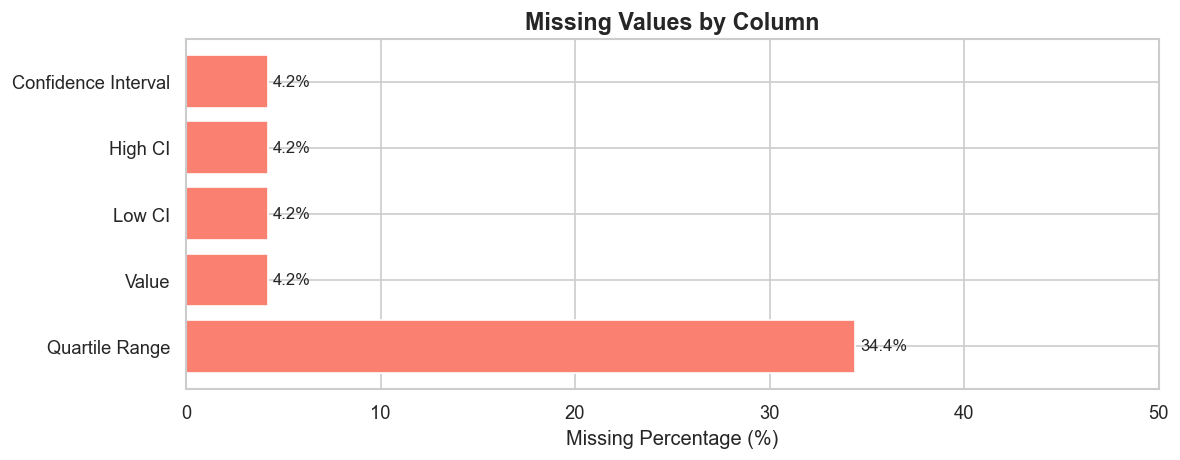

In [39]:
# ─── Visualize Missing Values ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing_df.index, missing_df['Missing %'], color=['salmon'])
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Values by Column')
ax.set_xlim(0, 50)
plt.tight_layout()
plt.show()

In [40]:
#  Cleaning Steps 
df_clean = df.copy()

df_clean.dropna(subset=['Value'], inplace=True)

# 2. Parse date columns
df_clean['Time Period Start Date'] = pd.to_datetime(df_clean['Time Period Start Date'], errors='coerce')
df_clean['Time Period End Date']   = pd.to_datetime(df_clean['Time Period End Date'],   errors='coerce')

indicator_map = {
    'Symptoms of Depressive Disorder': 'Depression',
    'Symptoms of Anxiety Disorder':    'Anxiety',
    'Symptoms of Anxiety Disorder or Depressive Disorder': 'Anxiety or Depression'
}
df_clean['Indicator_Short'] = df_clean['Indicator'].map(indicator_map)

df_clean['Year'] = df_clean['Time Period Start Date'].dt.year



---
## Section 3 — Exploratory Data Analysis (EDA)

In [41]:
# 3.1 Statistical Summary

df_clean[['Value', 'Low CI', 'High CI']].describe().round(2)

,Value,Low CI,High CI
count,16087.00,16087.00,16087.00
mean,28.14,24.64,31.89
std,8.95,8.59,9.48
min,4.60,3.30,6.00
25%,22.10,18.70,25.50
50%,27.70,24.10,31.60
75%,33.40,29.70,37.40
max,85.20,79.90,89.50


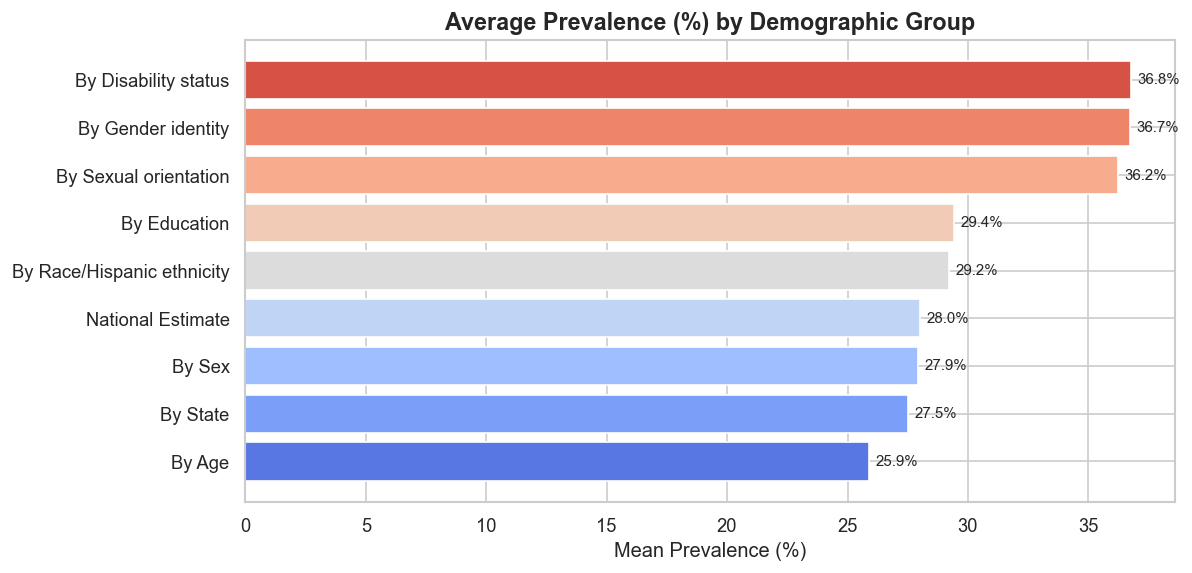

In [42]:
# 3.5 Mean Value by Group
group_mean = df_clean.groupby('Group')['Value'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(group_mean.index, group_mean.values,
               color=sns.color_palette('coolwarm', len(group_mean)))
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9)
ax.set_title('Average Prevalence (%) by Demographic Group')
ax.set_xlabel('Mean Prevalence (%)')


plt.show()

---
##  Section 4 — Advanced Visualizations

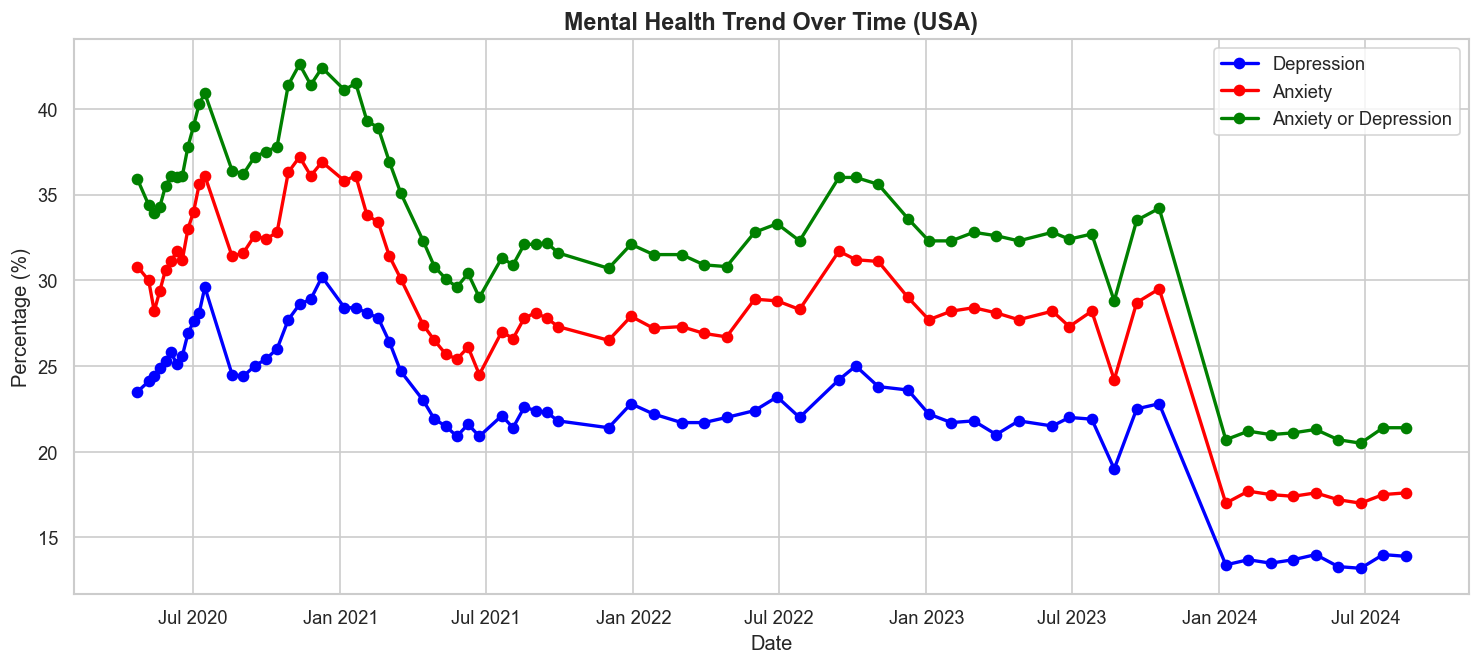

In [43]:
national = df_clean[
    (df_clean['Group'] == 'National Estimate') & 
    (df_clean['State'] == 'United States')
].copy()


national['Time Period Start Date'] = pd.to_datetime(national['Time Period Start Date'])


national = national.sort_values('Time Period Start Date')


fig, ax = plt.subplots(figsize=(15, 6))

colors = ['blue', 'red', 'green'] 

for ind, color in zip(national['Indicator_Short'].unique(), colors):
    subset = national[national['Indicator_Short'] == ind]
    
    ax.plot(
        subset['Time Period Start Date'],
        subset['Value'],
        marker='o',
        linewidth=2,
        label=ind,
        color=color
    )


ax.set_title('Mental Health Trend Over Time (USA)')
ax.set_xlabel('Date')
ax.set_ylabel('Percentage (%)')


ax.legend()


ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))


plt.xticks(rotation=0)


plt.grid(True)


plt.show()

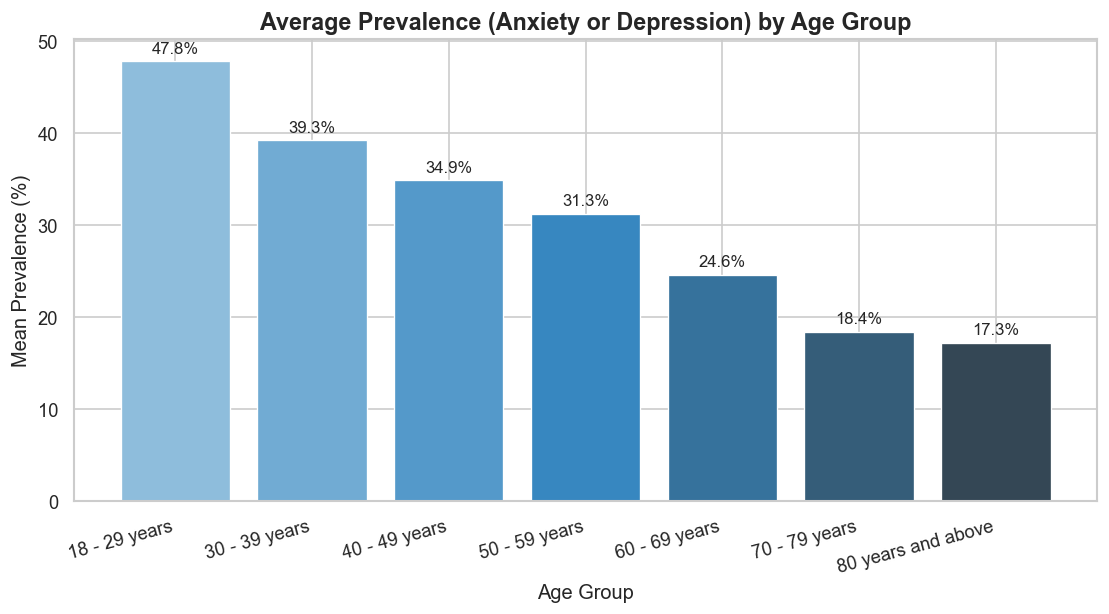

In [44]:
# 4.2 Trend by Age Group
age_groups = ['18 - 29 years', '30 - 39 years', '40 - 49 years',
              '50 - 59 years', '60 - 69 years', '70 - 79 years', '80 years and above']

age_data = df_clean[
    (df_clean['Group'] == 'By Age') &
    (df_clean['Indicator_Short'] == 'Anxiety or Depression') &
    (df_clean['Subgroup'].isin(age_groups))
].groupby('Subgroup')['Value'].mean().reindex(age_groups)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(age_data.index, age_data.values,
              color=sns.color_palette('Blues_d', len(age_data)),linewidth=0.8)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
ax.set_title('Average Prevalence (Anxiety or Depression) by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Mean Prevalence (%)')
plt.xticks(rotation=15, ha='right')

plt.show()

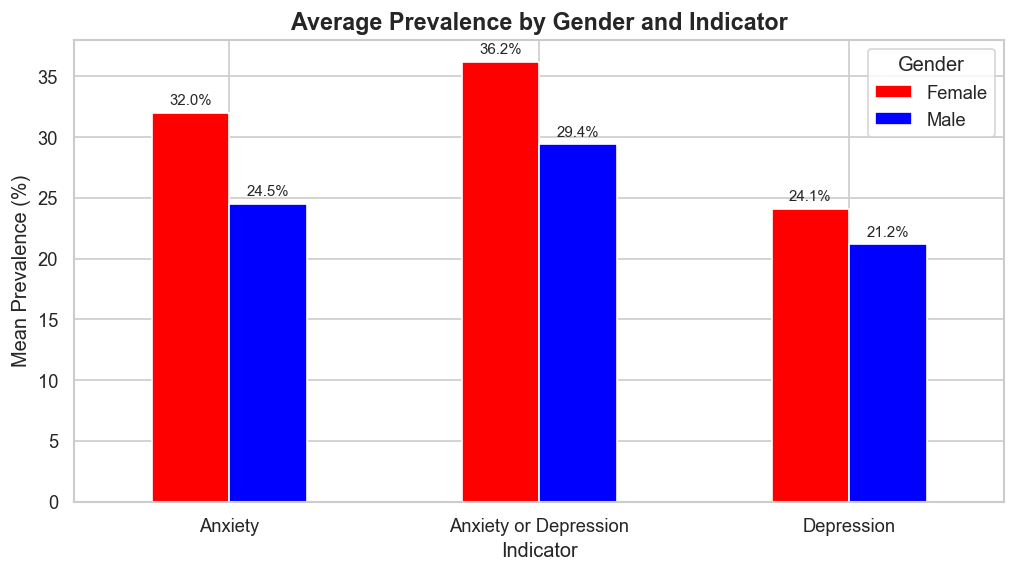

In [45]:
# 4.3 Gender Comparison
gender_data = df_clean[
    (df_clean['Group'] == 'By Sex') &
    (df_clean['Subgroup'].isin(['Male', 'Female']))
].groupby(['Indicator_Short', 'Subgroup'])['Value'].mean().unstack()

ax = gender_data.plot(kind='bar', figsize=(10, 5), color=['red', 'blue'])
ax.set_title('Average Prevalence by Gender and Indicator')
ax.set_xlabel('Indicator')
ax.set_ylabel('Mean Prevalence (%)')
ax.legend(title='Gender')
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)

plt.show()

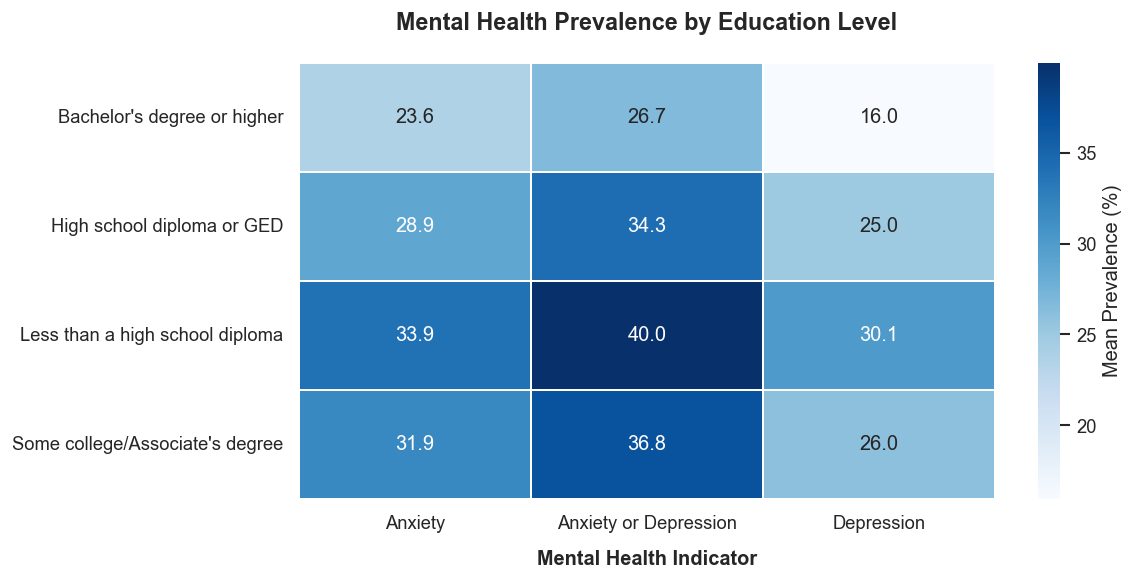

In [46]:
edu_data = df_clean[df_clean['Group'] == 'By Education'].groupby(['Subgroup', 'Indicator_Short'])['Value'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

sns.heatmap(edu_data, annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': 'Mean Prevalence (%)'}, linewidths=1, ax=ax)

ax.set_title('Mental Health Prevalence by Education Level', fontweight='bold', pad=20)
ax.set_xlabel('Mental Health Indicator', fontweight='bold', labelpad=10)
ax.set_ylabel('', fontweight='bold')

plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

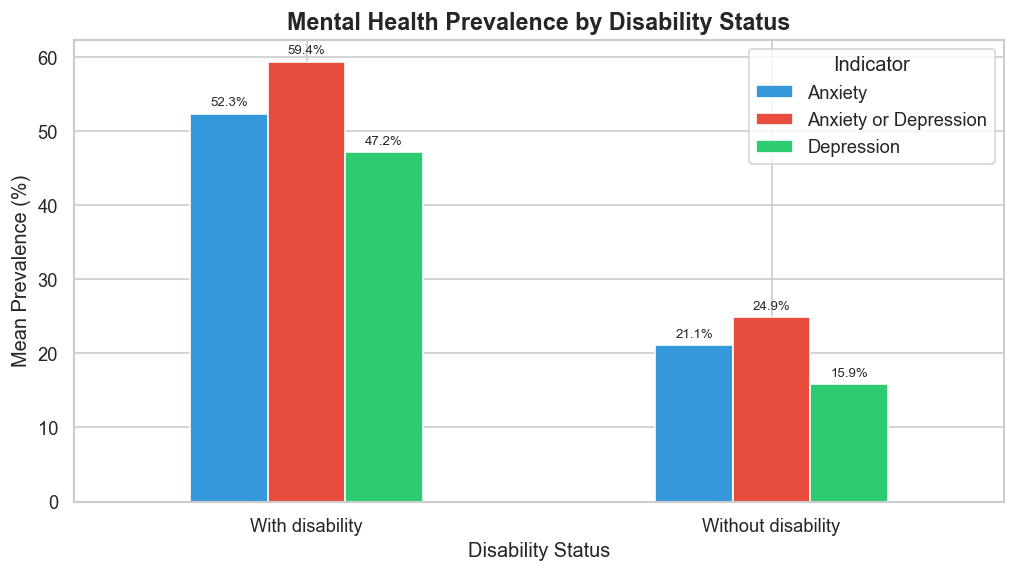

In [47]:
# 4.5 Disability Status Impact
disability_data = df_clean[
    df_clean['Group'] == 'By Disability status'
].groupby(['Subgroup', 'Indicator_Short'])['Value'].mean().unstack()

ax = disability_data.plot(kind='bar', figsize=(10, 5),
                          color=['#3498db', '#e74c3c', '#2ecc71']
                         )
ax.set_title('Mental Health Prevalence by Disability Status')
ax.set_xlabel('Disability Status')
ax.set_ylabel('Mean Prevalence (%)')
ax.legend(title='Indicator')
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=8)

plt.show()

---
## Section 5 — Dashboard




In [48]:

sns.set_theme(style='whitegrid', palette='muted', rc={'axes.facecolor': 'none', 'figure.facecolor': 'none'})

df = pd.read_csv('mentalHealthRawdataset.csv').dropna(subset=['Value'])
df['Year'] = pd.to_datetime(df['Time Period Start Date'], errors='coerce').dt.year
df['Indicator'] = df['Indicator'].replace({
    'Symptoms of Depressive Disorder': 'Depressive',
    'Symptoms of Anxiety Disorder': 'Anxiety',
    'Symptoms of Anxiety Disorder or Depressive Disorder': 'Anxiety or Depression'
})

national = df[df['Group'] == 'National Estimate'].groupby(['Year', 'Indicator'])['Value'].mean().reset_index()

fig_line, ax_line = plt.subplots(figsize=(10, 5))
sns.lineplot(data=national, x='Year', y='Value', hue='Indicator', marker='o', ax=ax_line)
ax_line.set_title("National Mental Health Trends (Year-Wise Average)")
ax_line.set_ylabel("Percentage (%)")
plt.close(fig_line)

age_data = df[(df['Indicator'] == 'Anxiety or Depression') & (df['Group'] == 'By Age')].groupby('Subgroup')['Value'].mean().reset_index()

fig_bar, ax_bar = plt.subplots(figsize=(10, 5))
sns.barplot(data=age_data, x='Value', y='Subgroup', hue='Subgroup', ax=ax_bar, legend=False)
ax_bar.set_title("Average Prevalence by Age Group - Anxiety or Depression")
ax_bar.set_xlabel("Percentage (%)") 
ax_bar.set_ylabel("")
plt.close(fig_bar)


sidebar_text = """
### US Mental Health Overview
This dashboard provides summary of mental health trends (2020-2024).

---
**Key Insights:**
- Observe national yearly trends.
- Compare average prevalence across age groups.
"""

pn.template.FastListTemplate(
    title="Mental Health Analysis Dashboard",
    sidebar=[pn.pane.Markdown(sidebar_text)],
    main=[
        pn.pane.Matplotlib(fig_line, sizing_mode='stretch_width'),
        pn.pane.Matplotlib(fig_bar, sizing_mode='stretch_width')
    ],
   
    header_background="salmon",
  
    theme_toggle=False
).show()

Launching server at http://localhost:57517
